In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew, kurtosis


In [109]:
df = pd.read_csv('train.csv')

In [110]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [112]:
numerical_features = df.select_dtypes(include=['number']).columns.to_list()

In [113]:
categorical_features= df.select_dtypes(include=['str','category']).columns.to_list()

In [114]:
mean_value= df['SalePrice'].mean()
median_value= df['SalePrice'].median()

print(f"Mean: {mean_value}")
print(f"Median: {median_value}")


Mean: 180921.19589041095
Median: 163000.0


In [115]:
skewness = skew(df['SalePrice'])
kurt = kurtosis(df['SalePrice'])
print(skewness)
print(kurt)

1.880940746034036
6.509812011089439


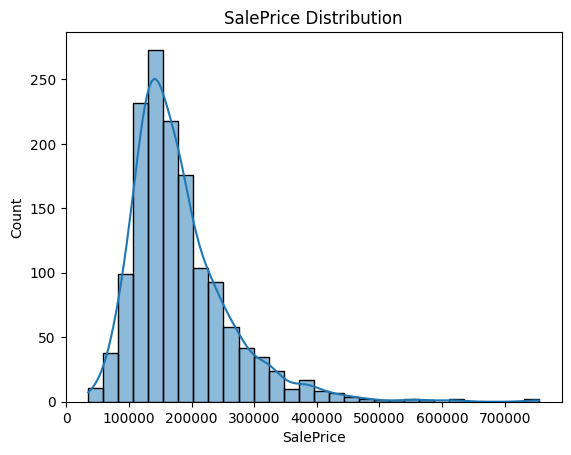

In [116]:
# Histogram
plt.Figure(figsize=(8,5))
sns.histplot(df['SalePrice'],kde=True,bins=30)
plt.title('SalePrice Distribution')
plt.show()



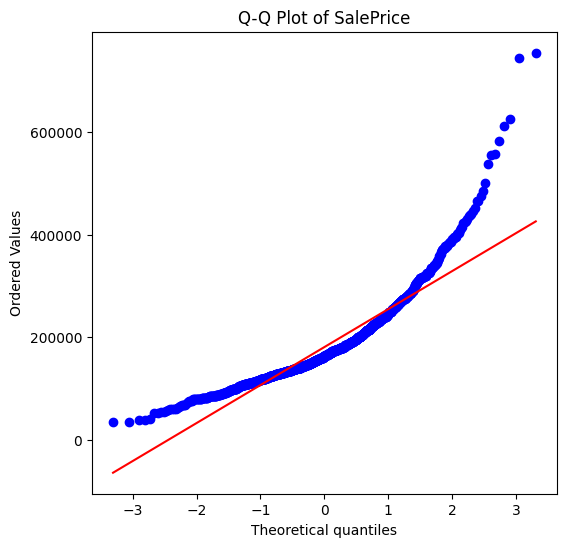

In [117]:
# Q-Q plot
plt.figure(figsize=(6,6))
stats.probplot(df['SalePrice'], dist="norm", plot=plt)
plt.title('Q-Q Plot of SalePrice')
plt.show()

Text(0.5, 1.0, 'Log-Transform SalePrice')

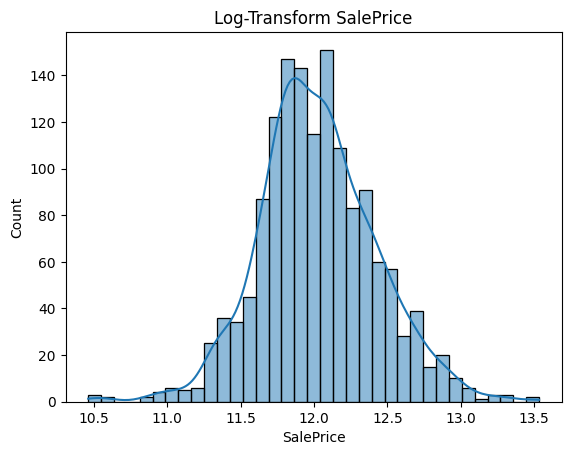

In [118]:
sns.histplot(np.log(df['SalePrice']),kde=True)
plt.title("Log-Transform SalePrice")

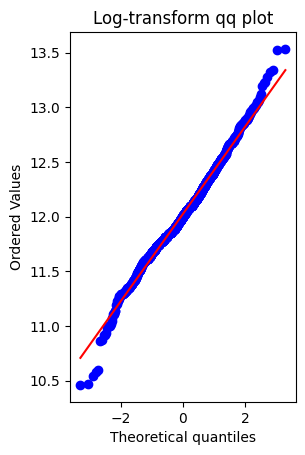

In [119]:
plt.subplot(1,2,2)
stats.probplot(np.log(df['SalePrice']),dist="norm",plot=plt)
plt.title('Log-transform qq plot')
plt.show()

In [120]:
# phase 2
q1,q3= np.percentile(df['SalePrice'],[25,75])
print(q1,q3)

129975.0 214000.0


In [121]:
IQR= q3-q1
Lower_Bound= q1-1.5*(IQR)
Upper_Bound= q3+1.5*(IQR)
print(Lower_Bound,Upper_Bound)

3937.5 340037.5


In [122]:
print(df['SalePrice'].isnull().sum())

0


In [123]:
df_filter= df[(df['SalePrice'] >= Lower_Bound) & (df['SalePrice'] <=Upper_Bound)]
print(f"old data: {len(df)} ")
print(f"new data: {len(df_filter)}")

old data: 1460 
new data: 1399


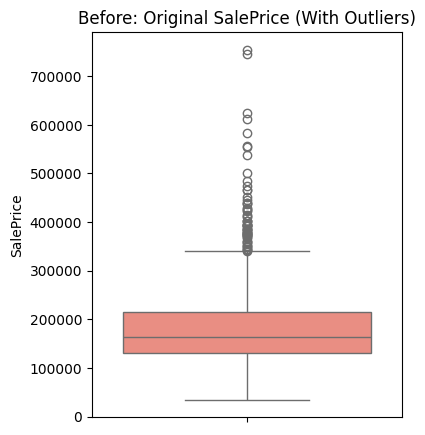

In [124]:
# Before Filtering
plt.figure(figsize=(4, 5))
sns.boxplot(y=df['SalePrice'], color='salmon')
plt.title('Before: Original SalePrice (With Outliers)')
plt.show()

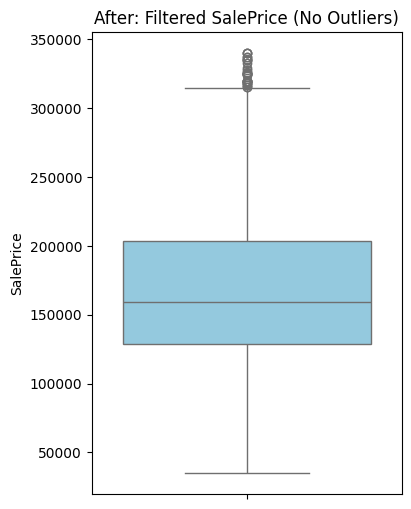

In [125]:
# After Filtering
plt.figure(figsize=(4, 6))
sns.boxplot(y=df_filter['SalePrice'], color='skyblue')
plt.title('After: Filtered SalePrice (No Outliers)')
plt.show()

In [126]:
print(df_filter.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [127]:

print(df_filter.info())

<class 'pandas.DataFrame'>
Index: 1399 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1399 non-null   int64  
 1   MSSubClass     1399 non-null   int64  
 2   MSZoning       1399 non-null   str    
 3   LotFrontage    1143 non-null   float64
 4   LotArea        1399 non-null   int64  
 5   Street         1399 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1399 non-null   str    
 8   LandContour    1399 non-null   str    
 9   Utilities      1399 non-null   str    
 10  LotConfig      1399 non-null   str    
 11  LandSlope      1399 non-null   str    
 12  Neighborhood   1399 non-null   str    
 13  Condition1     1399 non-null   str    
 14  Condition2     1399 non-null   str    
 15  BldgType       1399 non-null   str    
 16  HouseStyle     1399 non-null   str    
 17  OverallQual    1399 non-null   int64  
 18  OverallCond    1399 non-

In [128]:
num_df = df_filter.select_dtypes(include=['int64','float64'])
corr_with_price = num_df.corr()['SalePrice'].sort_values(ascending=False)
top10 = corr_with_price.drop('SalePrice').head(10)
print(top10)

OverallQual     0.784294
GrLivArea       0.661325
GarageCars      0.628013
GarageArea      0.607230
FullBath        0.577369
YearBuilt       0.564558
TotalBsmtSF     0.543508
YearRemodAdd    0.541161
1stFlrSF        0.522785
GarageYrBlt     0.507894
Name: SalePrice, dtype: float64


In [129]:
df_filter['OverallQual'].value_counts()

OverallQual
5     397
6     374
7     316
8     146
4     116
9      20
3      20
10      5
2       3
1       2
Name: count, dtype: int64

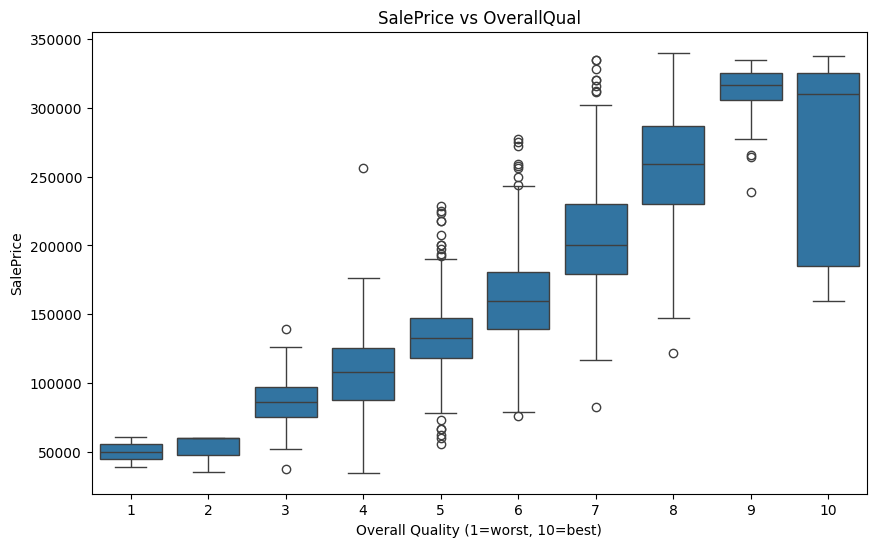

In [130]:
plt.figure(figsize=(10,6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df_filter)
plt.title('SalePrice vs OverallQual')
plt.xlabel('Overall Quality (1=worst, 10=best)')
plt.ylabel('SalePrice')
plt.show()

In [131]:
neigh_price = df_filter.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
print(neigh_price)

Neighborhood
NoRidge    282386.933333
NridgHt    260396.520000
StoneBr    239312.500000
Timber     230914.371429
Veenker    224150.000000
Somerst    221295.095238
ClearCr    212565.428571
Crawfor    200192.937500
CollgCr    195175.851351
Blmngtn    194870.882353
Gilbert    190487.256410
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      144958.004464
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
Edwards    128219.700000
OldTown    125129.098214
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


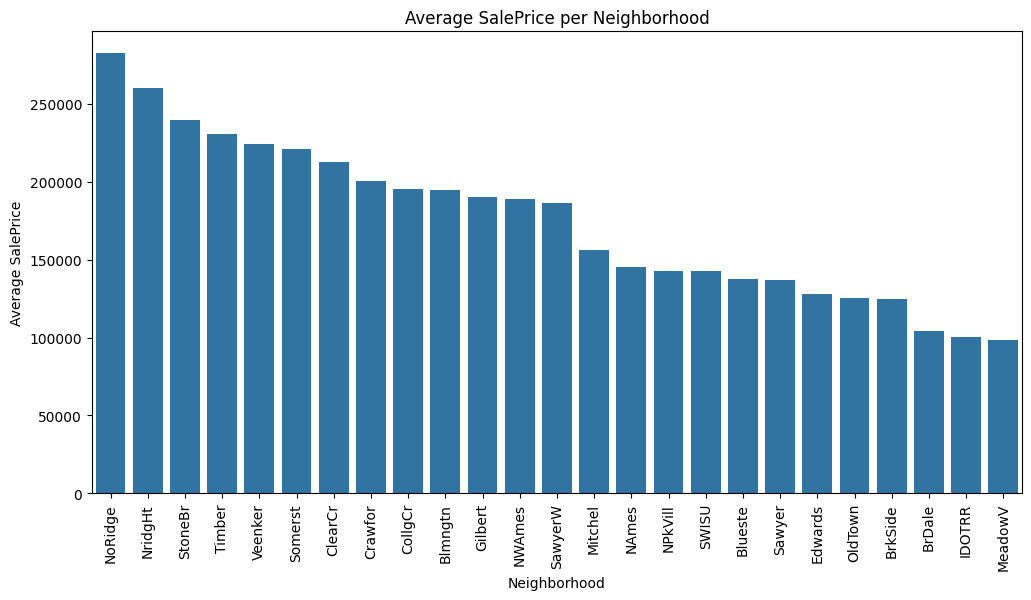

In [132]:
plt.figure(figsize=(12,6))
sns.barplot(x=neigh_price.index, y=neigh_price.values)
plt.xticks(rotation=90)
plt.title('Average SalePrice per Neighborhood')
plt.ylabel('Average SalePrice')
plt.xlabel('Neighborhood')
plt.show()


The bar chart clearly shows variation in average house prices across neighborhoods. NoRidge has the highest average SalePrice (~$282k), making it the most premium neighborhood in the dataset — essentially the "Beverly Hills" of Ames housing data

In [133]:
# phase 4
num_df = df_filter.select_dtypes(include=['int64','float64'])
corr_with_price = num_df.corr()['SalePrice'].sort_values(ascending=False)
print(corr_with_price.head(6))  


SalePrice      1.000000
OverallQual    0.784294
GrLivArea      0.661325
GarageCars     0.628013
GarageArea     0.607230
FullBath       0.577369
Name: SalePrice, dtype: float64


In [134]:
missing = df_filter.isnull().sum().sort_values(ascending=False)
missing_percent = (df_filter.isnull().sum()/len(df_filter))*100

missing_report = pd.concat([missing, missing_percent], axis=1)
missing_report.columns = ['Missing Count', 'Missing %']

print(missing_report[missing_report['Missing Count'] > 0])


              Missing Count  Missing %
PoolQC                 1393  99.571122
MiscFeature            1345  96.140100
Alley                  1308  93.495354
Fence                  1122  80.200143
MasVnrType              861  61.543960
FireplaceQu             689  49.249464
LotFrontage             256  18.298785
GarageQual               81   5.789850
GarageFinish             81   5.789850
GarageType               81   5.789850
GarageYrBlt              81   5.789850
GarageCond               81   5.789850
BsmtFinType2             38   2.716226
BsmtExposure             38   2.716226
BsmtCond                 37   2.644746
BsmtQual                 37   2.644746
BsmtFinType1             37   2.644746
MasVnrArea                7   0.500357
Electrical                1   0.071480


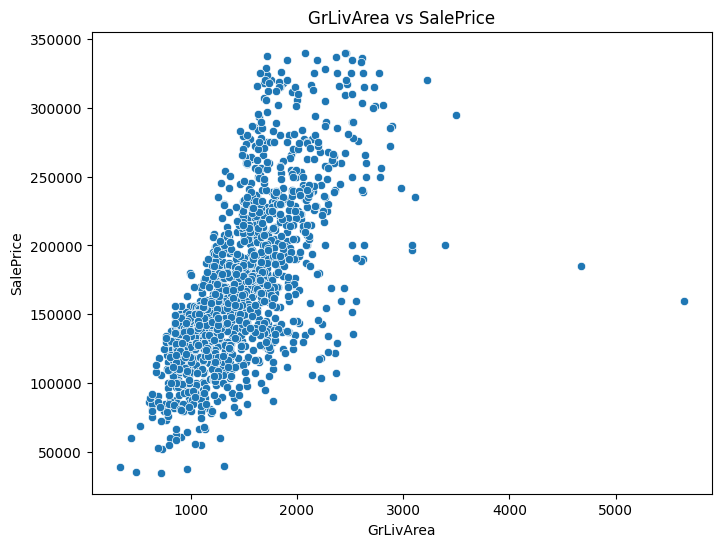

In [135]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_filter)
plt.title('GrLivArea vs SalePrice')
plt.show()


anagerial Report
Ames Housing Price Analysis
### 1. Top 3 Drivers of House Price
1. OverallQual (Overall Quality) – Correlation: 0.78
Strongest predictor of price.
Houses with higher construction and material quality (1–10 scale) have significantly higher prices.
Boxplot shows a clear step-by-step increase in median SalePrice as quality increases.

Managerial Insight:
Improving build quality provides the highest return on investment.

2. GrLivArea (Above-Ground Living Area) – Correlation: 0.66
Larger living area strongly increases house price.
Scatterplot shows a strong positive linear trend.
A few large-area outliers exist, but overall relationship is clear.

Managerial Insight:
Increasing usable living space directly increases property value.

3. GarageCars (Garage Capacity) – Correlation: 0.63
More garage capacity increases house desirability and price.
Functional features matter in valuation.

Managerial Insight:
Practical features such as parking space significantly influence pricing.

2. ### Anomaly Report – Missing Data Assessment
Features with Highest Missing Data
Feature	Missing %	Risk Level
PoolQC	99.5%	Very High
MiscFeature	96%	Very High
Alley	93%	Very High
Fence	80%	High
MasVnrType	61%	Moderate
FireplaceQu	49%	Moderate

Impact on Future Model
Very High Missing (>90%)
Likely indicate absence of feature rather than true missing error.
May be removed or converted to “None” category.
Limited predictive value.

Moderate Missing (40–60%)
Risk of bias if dropped blindly.
Should be imputed carefully (mode/indicator variable).

Low Missing (<10%)
Garage-related features (≈5%) and basement fields (~2–3%).
Safe to impute using median/mode.

Managerial Recommendation
Drop extremely sparse variables (>90% missing).
Impute moderate missing strategically.
Preserve high-impact features even if partially missing.

### 4. Visual Summary – 4 Most Impactful Charts
1. Correlation Analysis (Top Numeric Drivers)
Identified strongest relationships with SalePrice.
Highlighted OverallQual, GrLivArea, GarageCars as key drivers.

2. OverallQual vs SalePrice (Boxplot)
Clear upward trend in median prices as quality increases.
Strong evidence of quality-based market segmentation.

3. Average SalePrice per Neighborhood (Bar Chart)
Significant variation across neighborhoods.
NoRidge has the highest average price (~$282K) — the “Beverly Hills” of the dataset.
MeadowV has the lowest average price (~$98K).
Location has major pricing impact.

4. GrLivArea vs SalePrice (Scatterplot)
Strong positive linear relationship.
Larger homes generally sell for higher prices.
Minor outliers detected in very large properties.